<a href="https://colab.research.google.com/github/EdoardoCiato/eden_quant_tech_assessment/blob/main/CODE_trial_Team_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

cleanergy = pd.read_csv('/content/cleanergy_eod.csv', parse_dates=['Date']).set_index('Date').sort_index()
novaterra = pd.read_csv('/content/novaterra_eod.csv', parse_dates=['Date']).set_index('Date').sort_index()
orion = pd.read_csv('/content/orion_eod.csv', parse_dates=['Date']).set_index('Date').sort_index()

prices = pd.DataFrame({
    'Cleanergy': cleanergy['Close'],
    'NovaTerra': novaterra['Close'],
    'Orion': orion['Close']
}).dropna()

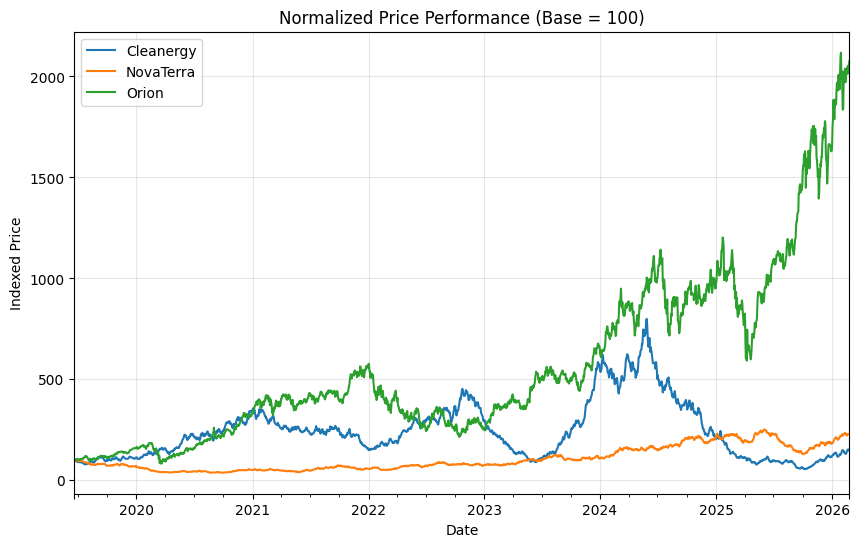

In [17]:
normalized = prices / prices.iloc[0] * 100

normalized.plot(figsize=(10,6))
plt.title('Normalized Price Performance (Base = 100)')
plt.ylabel('Indexed Price')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
summary = pd.DataFrame({
    'Start Price': prices.iloc[0],
    'End Price': prices.iloc[-1],
    'Total Return %': (prices.iloc[-1] / prices.iloc[0] - 1) * 100,
    'Annualized Vol %': prices.pct_change().std() * (252 ** 0.5) * 100,
    'Max Drawdown %': ((prices / prices.cummax()) - 1).min() * 100
})

summary.sort_values('Total Return %', ascending=False)

,Start Price,End Price,Total Return %,Annualized Vol %,Max Drawdown %
Orion,100.304717,2082.289791,1975.963974,56.578065,-62.757738
NovaTerra,13.681524,31.402579,129.525443,31.742653,-62.715209
Cleanergy,3.829386,5.605206,46.373492,46.029104,-93.044308


In [12]:
def load_price(path, name):
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df.sort_values("Date").set_index("Date")
    return df["Close"].rename(name)

    #Will put together the dates for the 3 businesses when they close at the same price and their differences

cleanergy = load_price("/content/cleanergy_eod.csv", "Cleanergy")
novaterra = load_price("/content/novaterra_eod.csv", "NovaTerra")
orion = load_price("/content/orion_eod.csv", "Orion")

prices = pd.concat([cleanergy, novaterra, orion], axis=1)

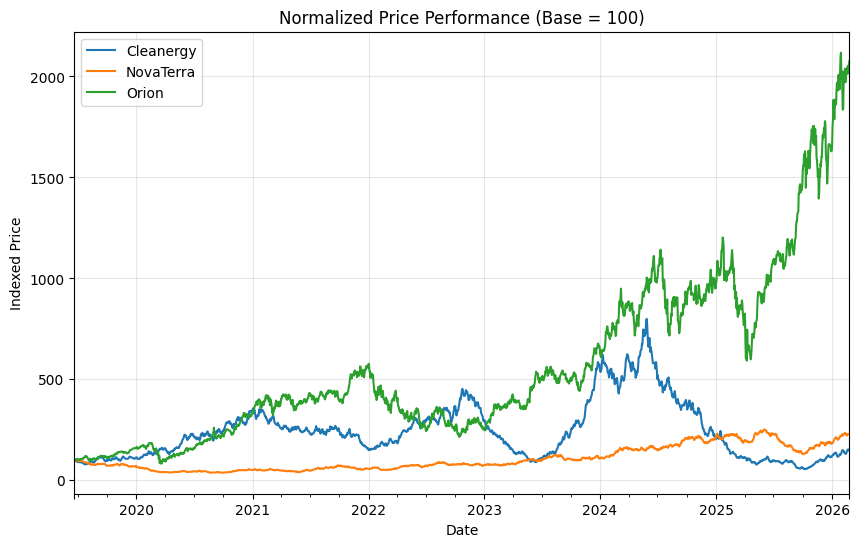

In [18]:
#Normalise for comparison

normalized = prices / prices.iloc[0] * 100

normalized.plot(figsize=(10,6))
plt.title('Normalized Price Performance (Base = 100)')
plt.ylabel('Indexed Price')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
#PORTFOLIO COMPARISON WITH YH PRICES

import yfinance as yf #AI help, alternative to download csv with prices

portfolio_tickers = ["ASML", "NVO", "PVH", "XLU", "GLD"]
portfolio_values = {"ASML": 5000, "NVO": 5000, "PVH": 7500, "XLU": 7500, "GLD": 10000}

def get_adj_close(tickers, start="2019-01-01"):
    raw = yf.download(tickers, start=start, auto_adjust=False, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        # try Adj Close at level 0 first, then level 1
        if "Adj Close" in raw.columns.get_level_values(0):
            return raw.xs("Adj Close", level=0, axis=1)
        else:
            return raw.xs("Adj Close", level=1, axis=1)
    else:
        return raw["Adj Close"]

base_prices = get_adj_close(portfolio_tickers)
base_returns = base_prices.pct_change().dropna()

base_weights = np.array([v / sum(portfolio_values.values()) for v in portfolio_values.values()])
base_port_ret = base_returns.dot(base_weights)

In [39]:
def compare_one_candidate(candidate_series, candidate_name, base_returns, base_weights, tickers, candidate_value=5000):
    candidate_returns = candidate_series['Close'].pct_change().dropna()
    candidate_returns.name = candidate_name

    # align dates across base portfolio and candidate
    aligned = pd.concat([base_returns, candidate_returns], axis=1).dropna()

    # rebuild the base portfolio on the common date range
    base_aligned = aligned[list(tickers.keys())]
    base_port = base_aligned.dot(base_weights)

    # new portfolio with candidate added
    new_total = sum(tickers.values()) + candidate_value
    new_weights = np.array([v / new_total for v in tickers.values()] + [candidate_value / new_total])

    new_port = aligned[list(tickers.keys()) + [candidate_name]].dot(new_weights)

    # metrics
    out = pd.Series({
        'Candidate': candidate_name,
        'Base Return': (1 + base_port).prod() - 1,
        'New Return': (1 + new_port).prod() - 1,
        'Base Vol': base_port.std() * np.sqrt(252),
        'New Vol': new_port.std() * np.sqrt(252),
        'Base Max DD': ((1 + base_port).cumprod() / (1 + base_port).cumprod().cummax() - 1).min(),
        'New Max DD': ((1 + new_port).cumprod() / (1 + new_port).cumprod().cummax() - 1).min(),
        'Correlation to Base': base_port.corr(candidate_returns.loc[base_port.index])
    })

    return out

In [40]:
results = []

for name, series in [('Orion', orion), ('Cleanergy', cleanergy), ('NovaTerra', novaterra)]:
    results.append(compare_one_candidate(series, name, base_returns, base_weights, portfolio_values, candidate_value=5000))

results_df = pd.DataFrame(results)
results_df

,Candidate,Base Return,New Return,Base Vol,New Vol,Base Max DD,New Max DD,Correlation to Base
0,Orion,2.007844,3.099267,0.204867,0.234901,-0.327732,-0.355846,0.691850
1,Cleanergy,2.578138,2.489254,0.201147,0.184611,-0.327732,-0.351408,-0.012194
2,NovaTerra,2.379034,2.339160,0.200358,0.182980,-0.327732,-0.325527,0.084275


In [23]:
#KPI Comparison TABLE idea

returns = common.pct_change().dropna()

def ann_return(s):
    years = (s.index[-1] - s.index[0]).days / 365.25
    return (s.iloc[-1] / s.iloc[0]) ** (1 / years) - 1

def max_drawdown(s):
    return (s / s.cummax() - 1).min()

summary = pd.DataFrame({
    "Annualized Return": [ann_return(common[c]) for c in common.columns],
    "Annualized Volatility": [returns[c].std() * np.sqrt(252) for c in common.columns],
    "Max Drawdown": [max_drawdown(common[c]) for c in common.columns],
    "Correlation vs Others": [returns[c].corr(returns.drop(columns=c).mean(axis=1)) for c in common.columns],
}, index=common.columns)

summary

,Annualized Return,Annualized Volatility,Max Drawdown,Correlation vs Others
Cleanergy,0.058640,0.460291,-0.930443,-0.014301
NovaTerra,0.132321,0.317427,-0.627152,0.055711
Orion,0.574043,0.565781,-0.627577,0.021607



Baseline portfolio
  Vol (ann.): 16.74%   Sharpe: 0.656
ASML      20.37
NOVO-B    13.84
PVH       43.19
XLU       12.47
GLD       10.13

+ Orion Chips
  Vol (ann.): 23.01%   Sharpe: 0.857
ASML           17.89
NOVO-B          5.41
PVH            34.48
XLU             9.99
GLD             5.94
Orion Chips    26.28

+ Cleanergy
  Vol (ann.): 17.57%   Sharpe: 0.673
ASML         18.92
NOVO-B        7.63
PVH          42.30
XLU          11.28
GLD           8.06
Cleanergy    11.81

+ NovaTerra AI
  Vol (ann.): 15.06%   Sharpe: 0.498
ASML            18.93
NOVO-B           8.56
PVH             42.39
XLU             11.85
GLD              8.91
NovaTerra AI     9.35


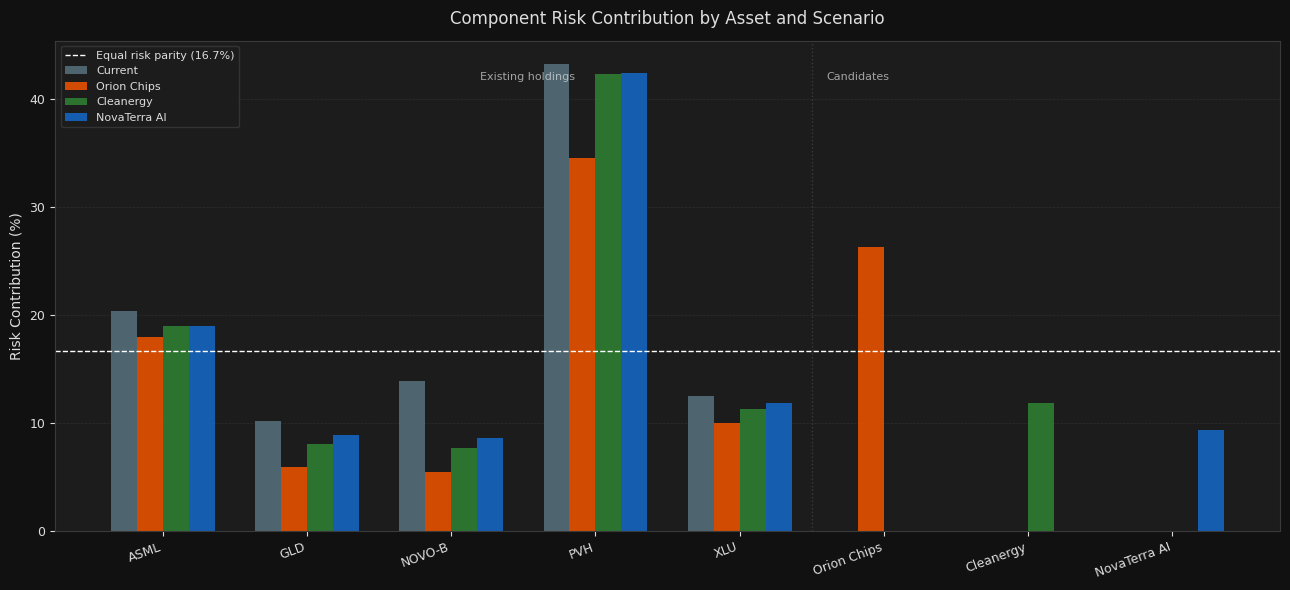

Saved: chart1_risk_contributions.png


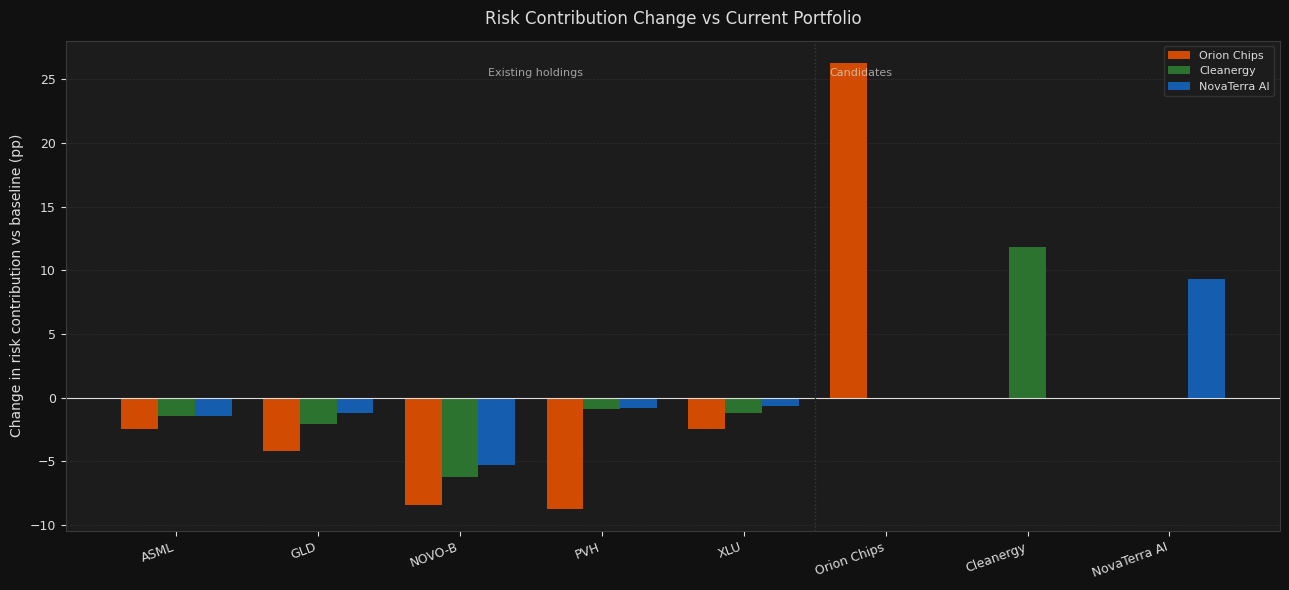

Saved: chart2_risk_delta.png


/tmp/ipykernel_7903/3675897850.py:258: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(scenarios, rotation=15, ha='right')


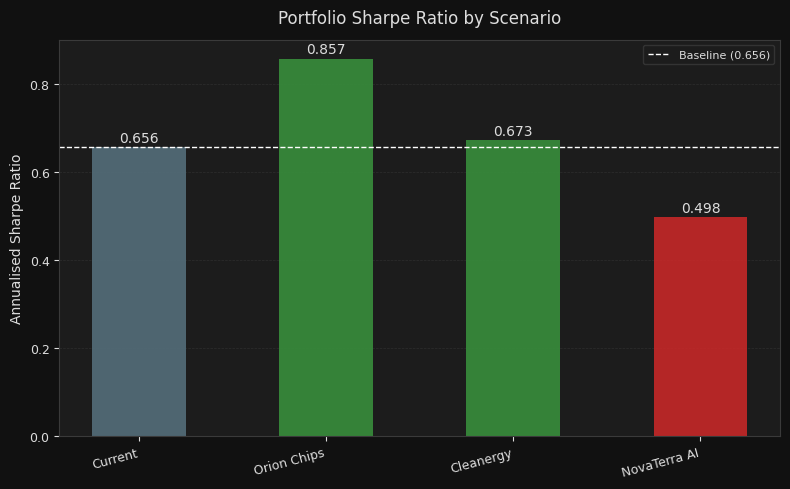


Summary
Scenario                    Vol   Sharpe    Delta  Verdict
------------------------------------------------------------
  Current                16.74%    0.656        —  Baseline
  Orion Chips            23.01%    0.857   +0.202  Add
  Cleanergy              17.57%    0.673   +0.017  Neutral
  NovaTerra AI           15.06%    0.498   -0.158  Avoid


In [4]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt

RISK_FREE_RATE = 0.04


def load_eden_csv(path, ticker):
    df = pd.read_csv(path)
    df = df[['Date', 'Close']].copy()
    df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')
    df = df.rename(columns={'Close': ticker})
    return df


def load_candidate_csv(path, ticker):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')
    df = df.rename(columns={'Close': ticker})
    return df


def build_price_matrix(eden_assets, candidate=None):
    merged = None
    for asset in eden_assets:
        df = load_eden_csv(asset['path'], asset['ticker'])
        merged = df if merged is None else merged.merge(df, on='Date', how='inner')
    if candidate is not None:
        cand_df = load_candidate_csv(candidate['path'], 'Candidate')
        merged = merged.merge(cand_df, on='Date', how='inner')
    merged = merged.set_index('Date').sort_index()
    return merged.dropna()


def compute_returns(price_df):
    return price_df.pct_change().dropna()


def risk_decomposition(returns_df, weights):
    w = np.array(weights)
    cov = returns_df.cov()
    port_vol_daily = math.sqrt(w @ cov.values @ w)
    marginal = (cov.values @ w) / port_vol_daily
    component = w * marginal
    pct_contrib = pd.Series(
        (component / port_vol_daily) * 100,
        index=returns_df.columns
    )
    port_vol_ann = port_vol_daily * np.sqrt(252)
    port_ret_ann = returns_df.mean() @ w * 252
    port_sharpe = (port_ret_ann - RISK_FREE_RATE) / port_vol_ann
    return pct_contrib, port_vol_ann, port_sharpe


def run_analysis(eden_assets, candidates):
    results = {}
    sharpe_dict = {}
    vol_dict = {}

    eden_total = sum(a['market value of shares'] for a in eden_assets)

    prices = build_price_matrix(eden_assets, candidate=None)
    returns = compute_returns(prices)
    weights = np.array([a['market value of shares'] / eden_total for a in eden_assets])

    contrib, vol, sharpe = risk_decomposition(returns, weights)
    results['Current'] = contrib
    sharpe_dict['Current'] = sharpe
    vol_dict['Current'] = vol

    print(f"\nBaseline portfolio")
    print(f"  Vol (ann.): {vol*100:.2f}%   Sharpe: {sharpe:.3f}")
    print(contrib.round(2).to_string())

    for cand in candidates:
        label = cand['ticker']
        prices = build_price_matrix(eden_assets, candidate=cand)
        returns = compute_returns(prices)
        new_total = eden_total + cand['market value of shares']
        weights = np.array(
            [a['market value of shares'] / new_total for a in eden_assets] +
            [cand['market value of shares'] / new_total]
        )
        contrib, vol, sharpe = risk_decomposition(returns, weights)
        contrib = contrib.rename({'Candidate': label})
        results[label] = contrib
        sharpe_dict[label] = sharpe
        vol_dict[label] = vol

        print(f"\n+ {label}")
        print(f"  Vol (ann.): {vol*100:.2f}%   Sharpe: {sharpe:.3f}")
        print(contrib.round(2).to_string())

    return results, sharpe_dict, vol_dict


COLORS = {
    'Current':      '#546E7A',
    'Orion Chips':  '#E65100',
    'Cleanergy':    '#2E7D32',
    'NovaTerra AI': '#1565C0',
}

DARK_BG   = '#111111'
PANEL_BG  = '#1C1C1C'
GRID_COL  = '#2E2E2E'
TEXT_COL  = '#DDDDDD'
SPINE_COL = '#3A3A3A'


def style_ax(ax):
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TEXT_COL, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COL)
    ax.yaxis.label.set_color(TEXT_COL)
    ax.title.set_color(TEXT_COL)
    ax.yaxis.grid(True, color=GRID_COL, linewidth=0.5, linestyle='--')
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COL)


def build_table(results):
    eden_assets = ['ASML', 'GLD', 'NOVO-B', 'PVH', 'XLU']
    cand_labels = ['Orion Chips', 'Cleanergy', 'NovaTerra AI']
    row_order = eden_assets + cand_labels
    table = pd.DataFrame(index=row_order)
    for scenario, contrib in results.items():
        col = {}
        for asset in eden_assets:
            col[asset] = contrib.get(asset, np.nan)
        if scenario != 'Current':
            col[scenario] = contrib.get(scenario, np.nan)
        table[scenario] = pd.Series(col)
    return table, row_order, eden_assets, cand_labels


def plot_absolute_contributions(results):
    table, row_order, eden_assets, cand_labels = build_table(results)
    scenarios = list(results.keys())
    equal_risk = 100 / 6

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor(DARK_BG)
    style_ax(ax)

    x = np.arange(len(row_order))
    bar_width = 0.18

    for i, scenario in enumerate(scenarios):
        vals = [table.loc[row, scenario] if row in table.index else np.nan
                for row in row_order]
        plot_vals = [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in vals]
        offset = (i - len(scenarios) / 2 + 0.5) * bar_width
        ax.bar(x + offset, plot_vals, bar_width,
               label=scenario, color=COLORS[scenario], alpha=0.9)

    ax.axhline(y=equal_risk, linestyle='--', color='white', linewidth=1.0,
               label=f'Equal risk parity ({equal_risk:.1f}%)')

    ax.axvline(x=len(eden_assets) - 0.5, color=SPINE_COL,
               linewidth=1.0, linestyle=':')

    ax.text(len(eden_assets) - 0.5 - 2.3, ax.get_ylim()[1] * 0.92,
            'Existing holdings', color=TEXT_COL, fontsize=8, alpha=0.7)
    ax.text(len(eden_assets) - 0.5 + 0.1, ax.get_ylim()[1] * 0.92,
            'Candidates', color=TEXT_COL, fontsize=8, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(row_order, rotation=20, ha='right')
    ax.set_ylabel('Risk Contribution (%)')
    ax.set_title('Component Risk Contribution by Asset and Scenario', pad=12)
    ax.legend(fontsize=8, facecolor=PANEL_BG, labelcolor=TEXT_COL,
              edgecolor=SPINE_COL, loc='upper left')

    plt.tight_layout()
    plt.savefig('chart1_risk_contributions.png', dpi=150,
                bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print("Saved: chart1_risk_contributions.png")


def plot_delta(results):
    table, row_order, eden_assets, cand_labels = build_table(results)
    scenarios = list(results.keys())
    cand_scenarios = [s for s in scenarios if s != 'Current']
    baseline = table['Current'].fillna(0)

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor(DARK_BG)
    style_ax(ax)

    x = np.arange(len(row_order))
    w = 0.26

    for i, scenario in enumerate(cand_scenarios):
        col = table[scenario].fillna(0)
        delta = col - baseline
        offset = (i - len(cand_scenarios) / 2 + 0.5) * w
        ax.bar(x + offset, delta, w,
               label=scenario, color=COLORS[scenario], alpha=0.9)

    ax.axhline(y=0, color=TEXT_COL, linewidth=0.8)
    ax.axvline(x=len(eden_assets) - 0.5, color=SPINE_COL,
               linewidth=1.0, linestyle=':')

    ax.text(len(eden_assets) - 0.5 - 2.3,
            ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else ax.get_ylim()[0] * 0.9,
            'Existing holdings', color=TEXT_COL, fontsize=8, alpha=0.7)
    ax.text(len(eden_assets) - 0.5 + 0.1,
            ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else ax.get_ylim()[0] * 0.9,
            'Candidates', color=TEXT_COL, fontsize=8, alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(row_order, rotation=20, ha='right')
    ax.set_ylabel('Change in risk contribution vs baseline (pp)')
    ax.set_title('Risk Contribution Change vs Current Portfolio', pad=12)
    ax.legend(fontsize=8, facecolor=PANEL_BG, labelcolor=TEXT_COL,
              edgecolor=SPINE_COL)

    plt.tight_layout()
    plt.savefig('chart2_risk_delta.png', dpi=150,
                bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print("Saved: chart2_risk_delta.png")


def plot_sharpe(sharpe_dict):
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor(DARK_BG)
    style_ax(ax)

    scenarios = list(sharpe_dict.keys())
    sharpes = list(sharpe_dict.values())
    baseline = sharpes[0]

    bar_colors = []
    for i, (s, v) in enumerate(zip(scenarios, sharpes)):
        if i == 0:
            bar_colors.append(COLORS['Current'])
        elif v > baseline:
            bar_colors.append('#388E3C')
        else:
            bar_colors.append('#C62828')

    bars = ax.bar(scenarios, sharpes, color=bar_colors, alpha=0.9, width=0.5)

    ax.axhline(y=baseline, linestyle='--', color='white', linewidth=1.0,
               label=f'Baseline ({baseline:.3f})')

    for bar, val in zip(bars, sharpes):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                color=TEXT_COL, fontsize=10)

    ax.set_xticklabels(scenarios, rotation=15, ha='right')
    ax.set_ylabel('Annualised Sharpe Ratio')
    ax.set_title('Portfolio Sharpe Ratio by Scenario', pad=12)
    ax.legend(fontsize=8, facecolor=PANEL_BG, labelcolor=TEXT_COL,
              edgecolor=SPINE_COL)

    plt.tight_layout()
    plt.savefig('chart3_sharpe.png', dpi=150,
                bbox_inches='tight', facecolor=DARK_BG)
    plt.show()


def print_verdict(sharpe_dict, vol_dict):
    baseline_sharpe = sharpe_dict['Current']
    print("\n" + "="*60)
    print("Summary")
    print("="*60)
    print(f"{'Scenario':<22} {'Vol':>8} {'Sharpe':>8} {'Delta':>8}  Verdict")
    print("-"*60)
    for scenario, sharpe in sharpe_dict.items():
        vol = vol_dict[scenario]
        if scenario == 'Current':
            print(f"  {scenario:<20} {vol*100:>7.2f}% {sharpe:>8.3f} {'—':>8}  Baseline")
        else:
            delta = sharpe - baseline_sharpe
            if delta > 0.02:
                verdict = "Add"
            elif delta > -0.02:
                verdict = "Neutral"
            else:
                verdict = "Avoid"
            print(f"  {scenario:<20} {vol*100:>7.2f}% {sharpe:>8.3f} {delta:>+8.3f}  {verdict}")
    print("="*60)


def main():
    eden_assets = [
        {'ticker': 'ASML',   'market value of shares': 5000,  'path': 'ASML_1d_data.csv'},
        {'ticker': 'NOVO-B', 'market value of shares': 5000,  'path': 'NOVO-B.CO_1d_data.csv'},
        {'ticker': 'PVH',    'market value of shares': 7500,  'path': 'PVH_1d_data.csv'},
        {'ticker': 'XLU',    'market value of shares': 7500,  'path': 'XLU_1d_data.csv'},
        {'ticker': 'GLD',    'market value of shares': 10000, 'path': 'GLD_1d_data.csv'},
    ]

    candidates = [
        {'ticker': 'Orion Chips',  'market value of shares': 5000, 'path': 'orion_eod.csv'},
        {'ticker': 'Cleanergy',    'market value of shares': 5000, 'path': 'cleanergy_eod.csv'},
        {'ticker': 'NovaTerra AI', 'market value of shares': 5000, 'path': 'novaterra_eod.csv'},
    ]

    results, sharpe_dict, vol_dict = run_analysis(eden_assets, candidates)

    plot_absolute_contributions(results)
    plot_delta(results)
    plot_sharpe(sharpe_dict)
    print_verdict(sharpe_dict, vol_dict)


if __name__ == '__main__':
    main()